# DANL Analysis by ANE Sensor

This notebook implements a DANL analysis based on `plot_danel.py`.
It loads per-sensor DANL vectors from CSV, validates them, builds a long-format table,
and reproduces the per-sensor DANL plot with additional summary metrics.

It also evaluates linearity for every sensor using a first-order model
`DANL(f) = m * f + b`, reporting slope, intercept, R², RMSE, MAE, and residual span.


In [16]:
from __future__ import annotations

import json
from pathlib import Path
from typing import Dict, List, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# -----------------------
# Configuration
# -----------------------
DANL_CSV_CANDIDATES = [
    Path("data/danl_resume_vectors.csv"),
    Path("danl_resume_vectors.csv"),
]
OUTPUT_DIR = Path("data/plots_danl")
PLOT_FILENAME = "danl_by_ane_sensor.png"
LINEARITY_FIT_PLOT_FILENAME = "danl_linearity_fit_by_sensor.png"
LINEARITY_RESIDUAL_PLOT_FILENAME = "danl_linearity_residual_by_sensor.png"
LINEARITY_PLOT_NCOLS = 2


In [17]:
def resolve_danl_csv_path(
    candidates: List[Path],  # Candidate CSV paths to probe in order
) -> Path:                  # First existing CSV path
    '''Resolve the DANL CSV path from a prioritized candidate list.

    Purpose:
    Keep the notebook robust to either repository layout used by scripts:
    CSV in `data/` or CSV at repository root.

    Parameters:
    candidates: Ordered list of candidate filesystem paths.

    Returns:
    Existing `Path` pointing to the DANL input CSV.

    Side effects:
    None.
    '''
    for csv_path in candidates:
        if csv_path.exists():
            return csv_path
    tested = ", ".join(str(path) for path in candidates)
    raise FileNotFoundError(f"Could not find DANL CSV. Tested: {tested}")


def parse_json_vector(
    text: object,  # JSON-encoded list from CSV cell
) -> np.ndarray:   # Parsed numeric vector
    '''Parse one JSON-encoded vector cell into a 1D float array.

    Purpose:
    Convert serialized frequency/DANL vectors from the CSV to numeric arrays
    that can be validated, plotted, and summarized.

    Parameters:
    text: Raw CSV cell value expected to contain a JSON list.

    Returns:
    1D numpy array of `float`.

    Side effects:
    None.
    '''
    if isinstance(text, (list, tuple, np.ndarray)):
        return np.asarray(text, dtype=float).ravel()

    parsed = json.loads(str(text))
    return np.asarray(parsed, dtype=float).ravel()


def load_danl_table(
    csv_path: Path,  # Input CSV path
) -> pd.DataFrame:  # Raw DANL dataframe
    '''Load the DANL CSV into a dataframe.

    Purpose:
    Centralize CSV reading and required-column validation before analysis.

    Parameters:
    csv_path: Location of the DANL CSV file.

    Returns:
    Raw dataframe with one row per sensor and vector columns.

    Side effects:
    Reads a CSV file from disk.
    '''
    table = pd.read_csv(csv_path)
    required_cols = {"sensor_ane", "Frequency_MHz", "Mean_DANL_dBFS"}
    missing = required_cols.difference(table.columns)
    if missing:
        missing_str = ", ".join(sorted(missing))
        raise KeyError(f"Missing required columns: {missing_str}")
    return table


def build_long_danl_table(
    raw_df: pd.DataFrame,  # Row-wise sensor vectors
) -> pd.DataFrame:          # Long-format table [sensor, freq, danl]
    '''Expand vector columns into long-format DANL samples.

    Purpose:
    Normalize row-wise vector storage into tidy samples so downstream plots
    and summary statistics can be computed consistently.

    Parameters:
    raw_df: Input dataframe with `Frequency_MHz` and `Mean_DANL_dBFS` vectors.

    Returns:
    Long-format dataframe with columns:
    `sensor_ane`, `frequency_mhz`, `mean_danl_dbfs`.

    Side effects:
    None.
    '''
    records: List[Dict[str, float | str]] = []

    # Expand each sensor row into one sample per frequency bin.
    for _, row in raw_df.iterrows():
        sensor = str(row["sensor_ane"])
        freqs_mhz = parse_json_vector(row["Frequency_MHz"])
        danl_dbfs = parse_json_vector(row["Mean_DANL_dBFS"])

        if freqs_mhz.size != danl_dbfs.size:
            raise ValueError(
                f"Length mismatch for sensor '{sensor}': "
                f"freq={freqs_mhz.size}, danl={danl_dbfs.size}"
            )

        for freq_mhz, danl_value_dbfs in zip(freqs_mhz, danl_dbfs):
            records.append(
                {
                    "sensor_ane": sensor,
                    "frequency_mhz": float(freq_mhz),
                    "mean_danl_dbfs": float(danl_value_dbfs),
                }
            )

    long_df = pd.DataFrame.from_records(records)
    if long_df.empty:
        raise ValueError("No DANL samples were parsed from the CSV")

    return long_df


def summarize_danl_by_sensor(
    long_df: pd.DataFrame,  # Long-format DANL samples
) -> pd.DataFrame:          # Summary metrics per sensor
    '''Compute per-sensor DANL summary statistics.

    Purpose:
    Provide a compact, quantitative comparison of DANL behavior across ANE
    sensors beyond visual inspection of curves.

    Parameters:
    long_df: Long-format DANL table with one row per (sensor, frequency).

    Returns:
    Summary table with count, central tendency, spread, and extrema in dBFS.

    Side effects:
    None.
    '''
    grouped = long_df.groupby("sensor_ane", sort=True)["mean_danl_dbfs"]
    summary = grouped.agg(["count", "mean", "median", "std", "min", "max"]).reset_index()
    summary = summary.rename(
        columns={
            "count": "n_points",
            "mean": "mean_dbfs",
            "median": "median_dbfs",
            "std": "std_dbfs",
            "min": "min_dbfs",
            "max": "max_dbfs",
        }
    )

    percentiles = grouped.quantile([0.10, 0.90]).unstack(level=1).reset_index()
    percentiles = percentiles.rename(columns={0.10: "p10_dbfs", 0.90: "p90_dbfs"})

    out = summary.merge(percentiles, on="sensor_ane", how="left")
    return out.sort_values(by="sensor_ane", kind="stable").reset_index(drop=True)


def plot_danl_by_sensor(
    long_df: pd.DataFrame,        # Long-format DANL samples
    output_dir: Path,             # Directory where figure is saved
    output_filename: str,         # Plot image filename
) -> Tuple[plt.Figure, plt.Axes, Path]:  # Figure, axes, saved path
    '''Plot DANL curves per ANE sensor and save the figure.

    Purpose:
    Reproduce the core plot from `plot_danel.py` in notebook form while
    keeping deterministic output storage for reports.

    Parameters:
    long_df: Long-format DANL table with one row per frequency sample.
    output_dir: Directory where the PNG file is written.
    output_filename: Name of the output PNG file.

    Returns:
    `(figure, axes, plot_path)` for optional post-processing.

    Side effects:
    Creates output directory and writes a PNG file to disk.
    '''
    fig, ax = plt.subplots(figsize=(12, 7))

    # Plot one curve per sensor with lightweight markers for sample visibility.
    for sensor_name, sensor_df in long_df.groupby("sensor_ane", sort=True):
        sensor_df = sensor_df.sort_values(by="frequency_mhz", kind="stable")
        ax.plot(
            sensor_df["frequency_mhz"].to_numpy(dtype=float),
            sensor_df["mean_danl_dbfs"].to_numpy(dtype=float),
            label=str(sensor_name),
            marker="o",
            markersize=2.5,
            linewidth=1.0,
            alpha=0.95,
        )

    ax.set_xlabel("Frequency (MHz)")
    ax.set_ylabel("Mean DANL (dBFS)")
    ax.set_title("DANL by ANE Sensor")
    ax.grid(True, alpha=0.35, linewidth=0.7)
    ax.legend(ncol=2, fontsize=8)

    output_dir.mkdir(parents=True, exist_ok=True)
    plot_path = output_dir / output_filename
    fig.tight_layout()
    fig.savefig(plot_path, dpi=150, bbox_inches="tight")

    return fig, ax, plot_path


def compute_sensor_linearity(
    long_df: pd.DataFrame,  # Long-format DANL samples
) -> Tuple[pd.DataFrame, Dict[str, Dict[str, np.ndarray]]]:
    '''Compute per-sensor linear fit metrics and residual vectors.

    Purpose:
    Quantify measurement linearity for each sensor by fitting a first-order
    model versus frequency and collecting residual-based quality metrics.

    Parameters:
    long_df: Long-format table with `sensor_ane`, `frequency_mhz`, and
        `mean_danl_dbfs` columns.

    Returns:
    Tuple with:
    1. `linearity_summary_df`: one row per sensor with linearity metrics.
    2. `fit_payload_by_sensor`: per-sensor vectors for measurements, fitted
       curve, and residuals used by plotting helpers.

    Side effects:
    None.
    '''
    summary_rows: List[Dict[str, float | int | str]] = []
    fit_payload_by_sensor: Dict[str, Dict[str, np.ndarray]] = {}

    # Fit one independent first-order model per sensor.
    for sensor_name, sensor_df in long_df.groupby("sensor_ane", sort=True):
        sensor_sorted = sensor_df.sort_values(by="frequency_mhz", kind="stable")

        freq_mhz = sensor_sorted["frequency_mhz"].to_numpy(dtype=float)
        danl_dbfs = sensor_sorted["mean_danl_dbfs"].to_numpy(dtype=float)
        finite_mask = np.isfinite(freq_mhz) & np.isfinite(danl_dbfs)
        freq_mhz = freq_mhz[finite_mask]
        danl_dbfs = danl_dbfs[finite_mask]

        if freq_mhz.size < 2:
            fit_dbfs = np.full_like(danl_dbfs, np.nan, dtype=float)
            residual_db = np.full_like(danl_dbfs, np.nan, dtype=float)
            slope_db_per_mhz = np.nan
            intercept_dbfs = np.nan
            r2_score = np.nan
            rmse_db = np.nan
            mae_db = np.nan
            max_abs_residual_db = np.nan
            residual_span_db = np.nan
        else:
            # Least-squares linear model DANL(f) = m * f + b.
            slope_db_per_mhz, intercept_dbfs = np.polyfit(freq_mhz, danl_dbfs, deg=1)
            fit_dbfs = slope_db_per_mhz * freq_mhz + intercept_dbfs
            residual_db = danl_dbfs - fit_dbfs

            # Residual metrics summarize absolute and distributional deviations.
            ss_res = float(np.nansum(residual_db ** 2))
            ss_tot = float(np.nansum((danl_dbfs - np.nanmean(danl_dbfs)) ** 2))
            r2_score = np.nan if ss_tot <= 0.0 else float(1.0 - (ss_res / ss_tot))

            rmse_db = float(np.sqrt(np.nanmean(residual_db ** 2)))
            mae_db = float(np.nanmean(np.abs(residual_db)))
            max_abs_residual_db = float(np.nanmax(np.abs(residual_db)))
            residual_span_db = float(np.nanmax(residual_db) - np.nanmin(residual_db))

        fit_payload_by_sensor[str(sensor_name)] = {
            "frequency_mhz": np.asarray(freq_mhz, dtype=float),
            "danl_dbfs": np.asarray(danl_dbfs, dtype=float),
            "fit_dbfs": np.asarray(fit_dbfs, dtype=float),
            "residual_db": np.asarray(residual_db, dtype=float),
        }

        summary_rows.append(
            {
                "sensor_ane": str(sensor_name),
                "n_points": int(freq_mhz.size),
                "slope_db_per_mhz": float(slope_db_per_mhz),
                "slope_db_per_ghz": float(slope_db_per_mhz * 1e3) if np.isfinite(slope_db_per_mhz) else np.nan,
                "intercept_dbfs": float(intercept_dbfs),
                "r2_score": float(r2_score),
                "rmse_db": float(rmse_db),
                "mae_db": float(mae_db),
                "max_abs_residual_db": float(max_abs_residual_db),
                "residual_span_db": float(residual_span_db),
            }
        )

    linearity_summary_df = pd.DataFrame(summary_rows).sort_values(by="sensor_ane", kind="stable").reset_index(drop=True)
    return linearity_summary_df, fit_payload_by_sensor


def plot_linearity_fit_by_sensor(
    linearity_summary_df: pd.DataFrame,            # Per-sensor linearity metrics
    fit_payload_by_sensor: Dict[str, Dict[str, np.ndarray]],  # Per-sensor vectors
    output_dir: Path,                              # Directory where figure is saved
    output_filename: str,                          # Plot image filename
    ncols: int = LINEARITY_PLOT_NCOLS,             # Number of subplot columns
) -> Tuple[plt.Figure, np.ndarray, Path]:          # Figure, axes grid, saved path
    '''Plot measured DANL and linear fit for every sensor in a subplot grid.

    Purpose:
    Provide direct visual inspection of linearity by overlaying measured curves
    and fitted lines, including fit-quality metrics in each subplot title.

    Parameters:
    linearity_summary_df: Table with per-sensor fit metrics.
    fit_payload_by_sensor: Mapping with frequency, measurements, and fit vectors.
    output_dir: Directory where the PNG file is written.
    output_filename: Name of the output PNG file.
    ncols: Number of columns in subplot grid.

    Returns:
    `(figure, axes_grid, plot_path)` for optional post-processing.

    Side effects:
    Creates output directory and writes a PNG file to disk.
    '''
    sensors = sorted(fit_payload_by_sensor.keys())
    if not sensors:
        raise ValueError("No sensors available for linearity plotting")

    ncols = max(1, int(ncols))
    nrows = int(np.ceil(len(sensors) / float(ncols)))
    fig, axes_grid = plt.subplots(nrows=nrows, ncols=ncols, figsize=(7.2 * ncols, 3.6 * nrows), squeeze=False)

    metrics_by_sensor = linearity_summary_df.set_index("sensor_ane")

    # Draw one panel per sensor to compare measured curve against its linear fit.
    for axis, sensor_name in zip(axes_grid.ravel(), sensors):
        payload = fit_payload_by_sensor[sensor_name]
        freq_mhz = payload["frequency_mhz"]
        danl_dbfs = payload["danl_dbfs"]
        fit_dbfs = payload["fit_dbfs"]

        axis.plot(freq_mhz, danl_dbfs, marker="o", markersize=2.4, linewidth=0.9, alpha=0.9, label="Measured")
        axis.plot(freq_mhz, fit_dbfs, linewidth=1.6, color="black", alpha=0.95, label="Linear fit")

        sensor_metrics = metrics_by_sensor.loc[sensor_name]
        r2_text = "nan" if not np.isfinite(sensor_metrics["r2_score"]) else f"{sensor_metrics['r2_score']:.4f}"
        rmse_text = "nan" if not np.isfinite(sensor_metrics["rmse_db"]) else f"{sensor_metrics['rmse_db']:.3f}"
        slope_text = "nan" if not np.isfinite(sensor_metrics["slope_db_per_ghz"]) else f"{sensor_metrics['slope_db_per_ghz']:.3f}"

        axis.set_title(f"{sensor_name} | R²={r2_text} | RMSE={rmse_text} dB | slope={slope_text} dB/GHz", fontsize=9)
        axis.set_xlabel("Frequency (MHz)")
        axis.set_ylabel("Mean DANL (dBFS)")
        axis.grid(True, alpha=0.3, linewidth=0.7)
        axis.legend(fontsize=7, loc="best")

    # Hide unused axes when sensor count does not fill the grid.
    for axis in axes_grid.ravel()[len(sensors):]:
        axis.set_visible(False)

    output_dir.mkdir(parents=True, exist_ok=True)
    plot_path = output_dir / output_filename
    fig.tight_layout()
    fig.savefig(plot_path, dpi=150, bbox_inches="tight")

    return fig, axes_grid, plot_path


def plot_linearity_residual_by_sensor(
    linearity_summary_df: pd.DataFrame,            # Per-sensor linearity metrics
    fit_payload_by_sensor: Dict[str, Dict[str, np.ndarray]],  # Per-sensor vectors
    output_dir: Path,                              # Directory where figure is saved
    output_filename: str,                          # Plot image filename
    ncols: int = LINEARITY_PLOT_NCOLS,             # Number of subplot columns
) -> Tuple[plt.Figure, np.ndarray, Path]:          # Figure, axes grid, saved path
    '''Plot residuals versus frequency for every sensor in a subplot grid.

    Purpose:
    Visualize non-linearity directly as the deviation from each sensor's
    first-order model across frequency.

    Parameters:
    linearity_summary_df: Table with per-sensor fit metrics.
    fit_payload_by_sensor: Mapping with frequency and residual vectors.
    output_dir: Directory where the PNG file is written.
    output_filename: Name of the output PNG file.
    ncols: Number of columns in subplot grid.

    Returns:
    `(figure, axes_grid, plot_path)` for optional post-processing.

    Side effects:
    Creates output directory and writes a PNG file to disk.
    '''
    sensors = sorted(fit_payload_by_sensor.keys())
    if not sensors:
        raise ValueError("No sensors available for residual plotting")

    ncols = max(1, int(ncols))
    nrows = int(np.ceil(len(sensors) / float(ncols)))
    fig, axes_grid = plt.subplots(nrows=nrows, ncols=ncols, figsize=(7.2 * ncols, 3.3 * nrows), squeeze=False)

    metrics_by_sensor = linearity_summary_df.set_index("sensor_ane")

    # Plot residual traces to expose local frequency-dependent non-linear behavior.
    for axis, sensor_name in zip(axes_grid.ravel(), sensors):
        payload = fit_payload_by_sensor[sensor_name]
        freq_mhz = payload["frequency_mhz"]
        residual_db = payload["residual_db"]

        axis.plot(freq_mhz, residual_db, marker="o", markersize=2.2, linewidth=0.9, alpha=0.9)
        axis.axhline(0.0, color="black", linewidth=1.0, alpha=0.7)

        sensor_metrics = metrics_by_sensor.loc[sensor_name]
        span_text = "nan" if not np.isfinite(sensor_metrics["residual_span_db"]) else f"{sensor_metrics['residual_span_db']:.3f}"
        maxabs_text = "nan" if not np.isfinite(sensor_metrics["max_abs_residual_db"]) else f"{sensor_metrics['max_abs_residual_db']:.3f}"

        axis.set_title(f"{sensor_name} | span={span_text} dB | max|res|={maxabs_text} dB", fontsize=9)
        axis.set_xlabel("Frequency (MHz)")
        axis.set_ylabel("Residual (dB)")
        axis.grid(True, alpha=0.3, linewidth=0.7)

    # Hide unused axes when sensor count does not fill the grid.
    for axis in axes_grid.ravel()[len(sensors):]:
        axis.set_visible(False)

    output_dir.mkdir(parents=True, exist_ok=True)
    plot_path = output_dir / output_filename
    fig.tight_layout()
    fig.savefig(plot_path, dpi=150, bbox_inches="tight")

    return fig, axes_grid, plot_path


In [18]:
danl_csv_path = resolve_danl_csv_path(DANL_CSV_CANDIDATES)
raw_danl_df = load_danl_table(danl_csv_path)
long_danl_df = build_long_danl_table(raw_danl_df)

sensor_summary_df = summarize_danl_by_sensor(long_danl_df)
linearity_summary_df, linearity_fit_payload_by_sensor = compute_sensor_linearity(long_danl_df)

print(f"Loaded DANL CSV: {danl_csv_path}")
print(f"Rows (raw sensors): {len(raw_danl_df)}")
print(f"Rows (long samples): {len(long_danl_df)}")
print(f"Sensors: {long_danl_df['sensor_ane'].nunique()}")
print(f"Linearity summaries: {len(linearity_summary_df)}")


Loaded DANL CSV: data/danl_resume_vectors.csv
Rows (raw sensors): 10
Rows (long samples): 1191
Sensors: 10
Linearity summaries: 10


In [19]:
sensor_summary_df


,sensor_ane,n_points,mean_dbfs,median_dbfs,std_dbfs,min_dbfs,max_dbfs,p10_dbfs,p90_dbfs
0,ANE1,120,-80.509667,-79.045,2.797887,-84.13,-62.80,-83.760,-78.779
1,ANE10,119,-87.033193,-86.780,1.790028,-94.62,-85.05,-87.624,-85.688
2,ANE2,119,-90.197731,-90.290,0.396569,-90.98,-89.31,-90.642,-89.616
3,ANE3,119,-87.016807,-85.860,2.224806,-92.14,-84.12,-90.422,-84.964
4,ANE4,119,-81.810504,-81.400,1.550635,-92.35,-80.51,-82.796,-80.900
5,ANE5,119,-98.028319,-97.980,0.568659,-99.90,-96.96,-98.688,-97.424
6,ANE6,119,-107.237311,-108.100,1.598712,-109.15,-103.93,-108.722,-104.824
7,ANE7,119,-88.186387,-87.870,2.046531,-96.35,-84.62,-90.134,-86.356
8,ANE8,119,-88.374034,-87.790,4.349133,-108.36,-84.38,-91.312,-84.720
9,ANE9,119,-97.627563,-97.490,1.114305,-102.50,-95.20,-98.002,-96.852


In [20]:
linearity_summary_df


,sensor_ane,n_points,slope_db_per_mhz,slope_db_per_ghz,intercept_dbfs,r2_score,rmse_db,mae_db,max_abs_residual_db,residual_span_db
0,ANE1,120,0.000962,0.962410,-83.373623,0.357349,2.233575,1.244338,20.479306,22.728624
1,ANE10,119,-0.000197,-0.196740,-86.442974,0.035938,1.750169,0.950806,7.881916,9.324075
2,ANE2,119,-0.000130,-0.130436,-89.806424,0.321843,0.325201,0.268964,0.821400,1.526521
3,ANE3,119,0.001097,1.096730,-90.306996,0.722939,1.166130,0.973476,2.565826,4.927126
4,ANE4,119,-0.000048,-0.048455,-81.665140,0.002905,1.541862,0.826074,10.604910,11.779432
5,ANE5,119,0.000120,0.119711,-98.387452,0.131841,0.527618,0.416416,1.722042,2.808318
6,ANE6,119,-0.000779,-0.778842,-104.900785,0.706066,0.863103,0.716463,2.054816,3.786447
7,ANE7,119,0.000439,0.439419,-89.504643,0.137154,1.893009,1.254055,7.570398,10.884232
8,ANE8,119,-0.000523,-0.522941,-86.805210,0.043012,4.236659,2.594970,20.299731,25.048824
9,ANE9,119,0.000074,0.073857,-97.849134,0.013070,1.102338,0.609770,4.883516,7.203986


Saved DANL plot to: data/plots_danl/danl_by_ane_sensor.png


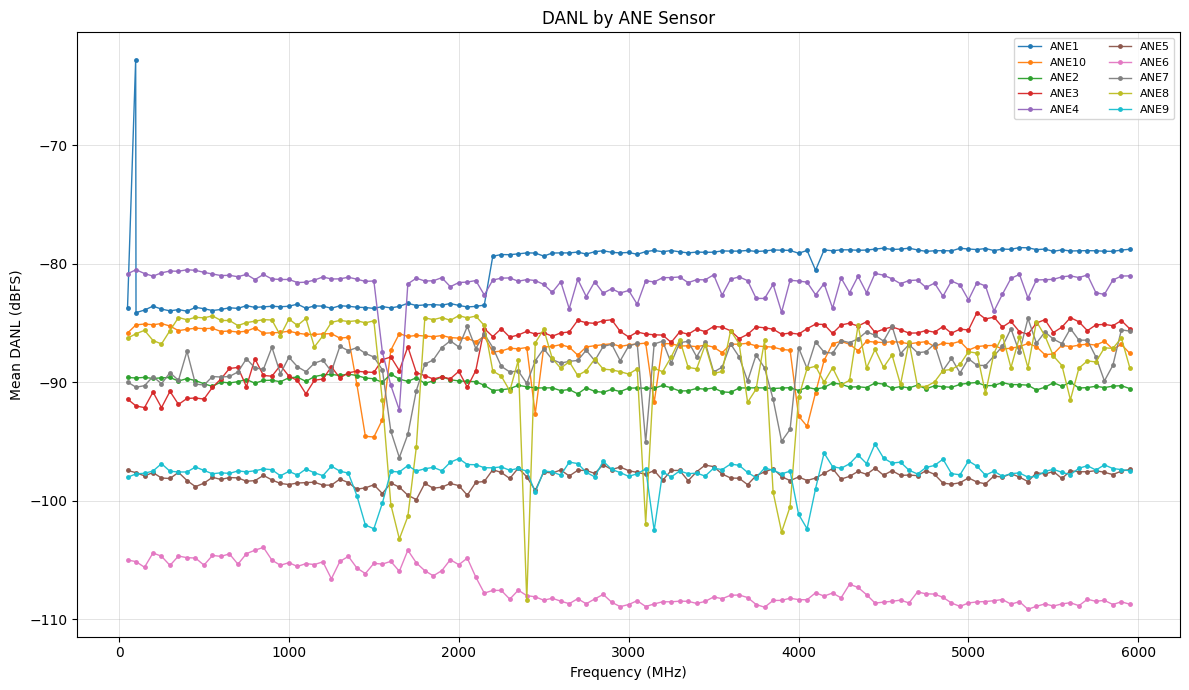

In [21]:
fig, ax, danl_plot_path = plot_danl_by_sensor(
    long_df=long_danl_df,
    output_dir=OUTPUT_DIR,
    output_filename=PLOT_FILENAME,
)
print(f"Saved DANL plot to: {danl_plot_path}")
plt.show()


Saved linearity fit plot to: data/plots_danl/danl_linearity_fit_by_sensor.png


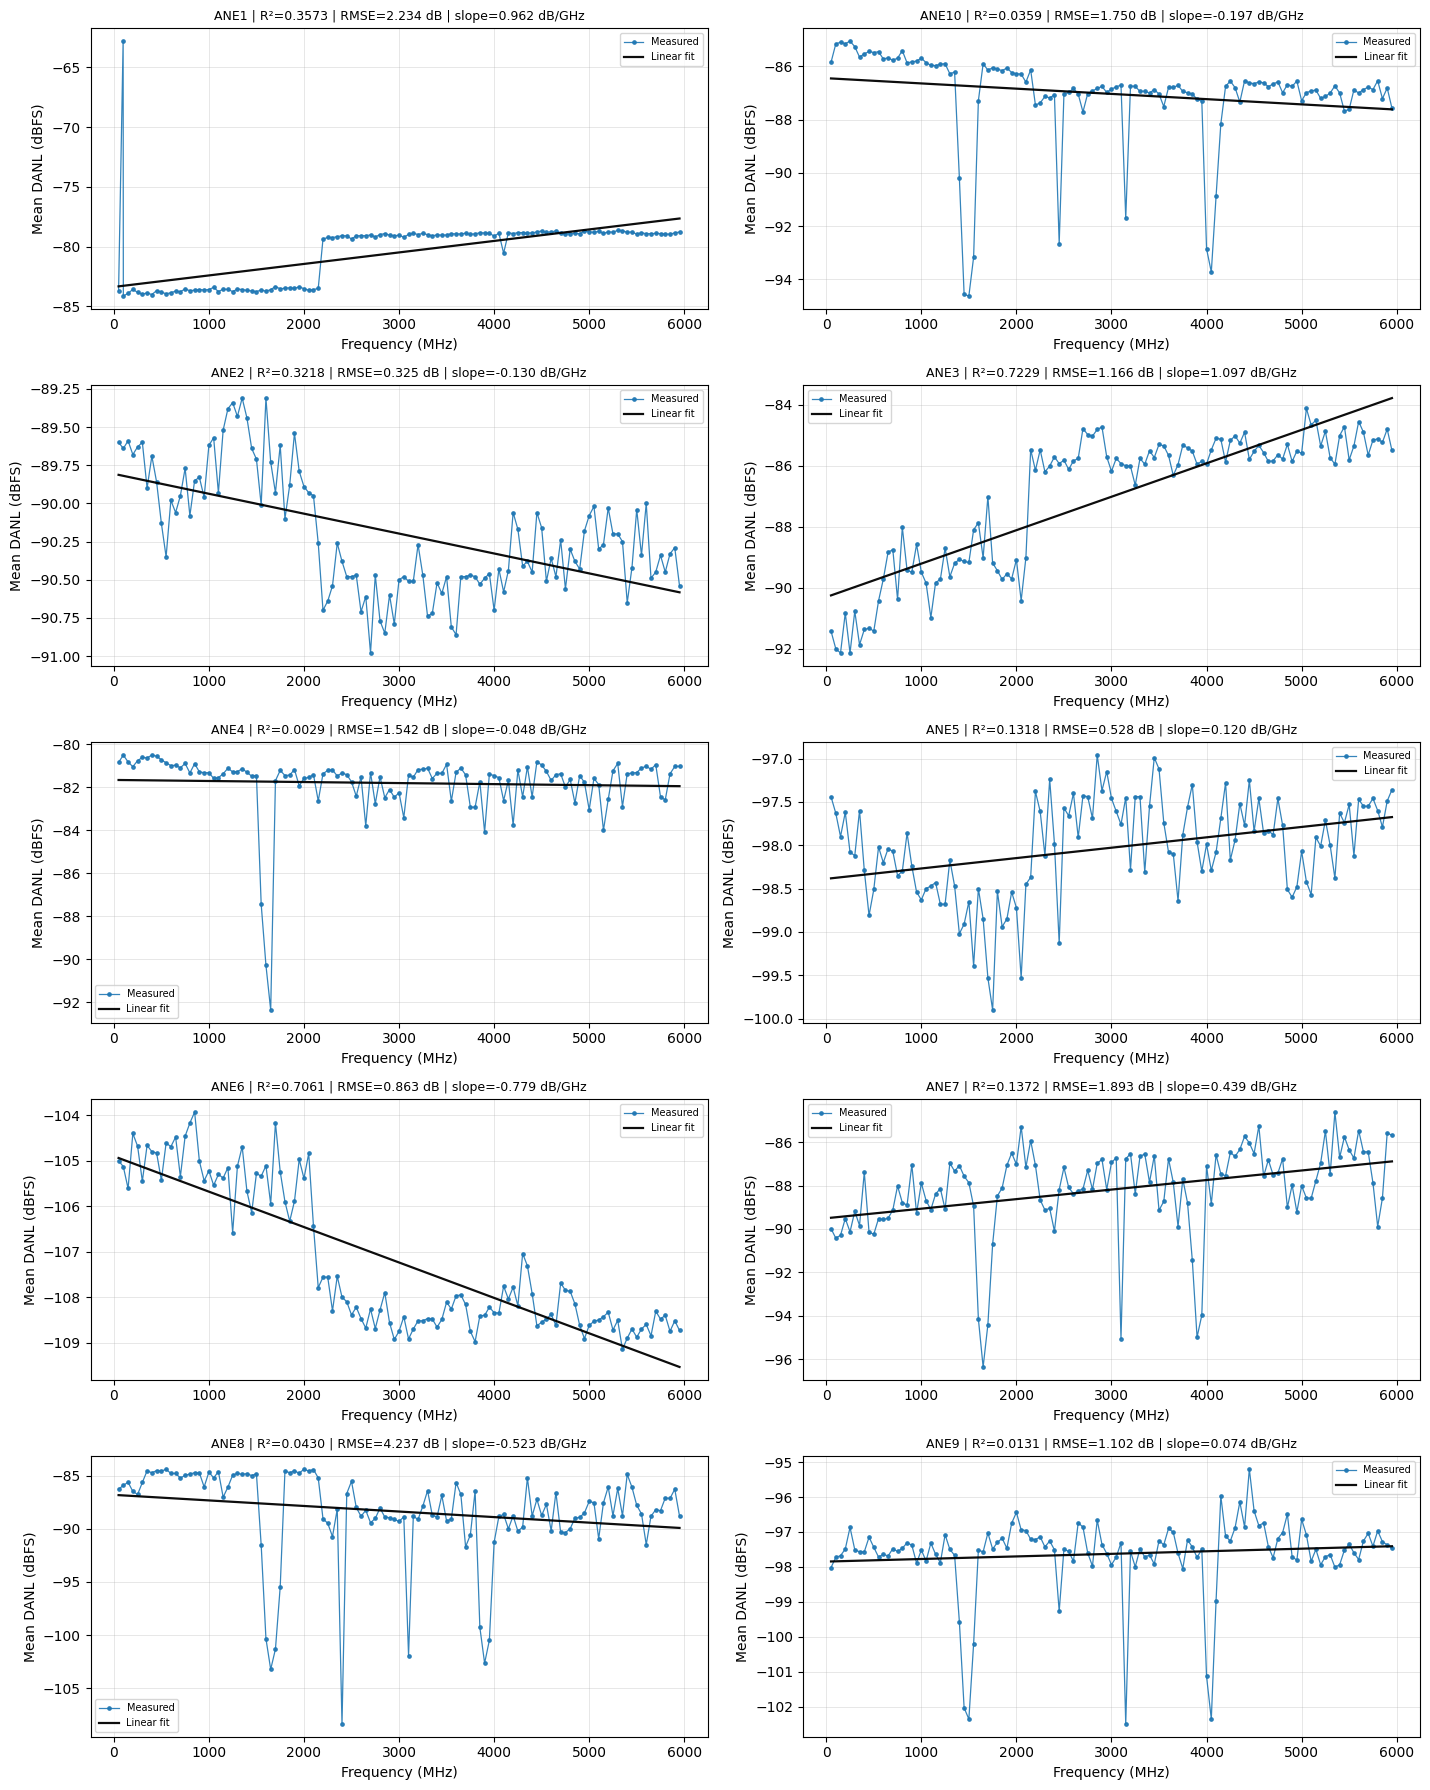

In [22]:
fit_fig, fit_axes, linearity_fit_plot_path = plot_linearity_fit_by_sensor(
    linearity_summary_df=linearity_summary_df,
    fit_payload_by_sensor=linearity_fit_payload_by_sensor,
    output_dir=OUTPUT_DIR,
    output_filename=LINEARITY_FIT_PLOT_FILENAME,
    ncols=LINEARITY_PLOT_NCOLS,
)
print(f"Saved linearity fit plot to: {linearity_fit_plot_path}")
plt.show()


Saved linearity residual plot to: data/plots_danl/danl_linearity_residual_by_sensor.png


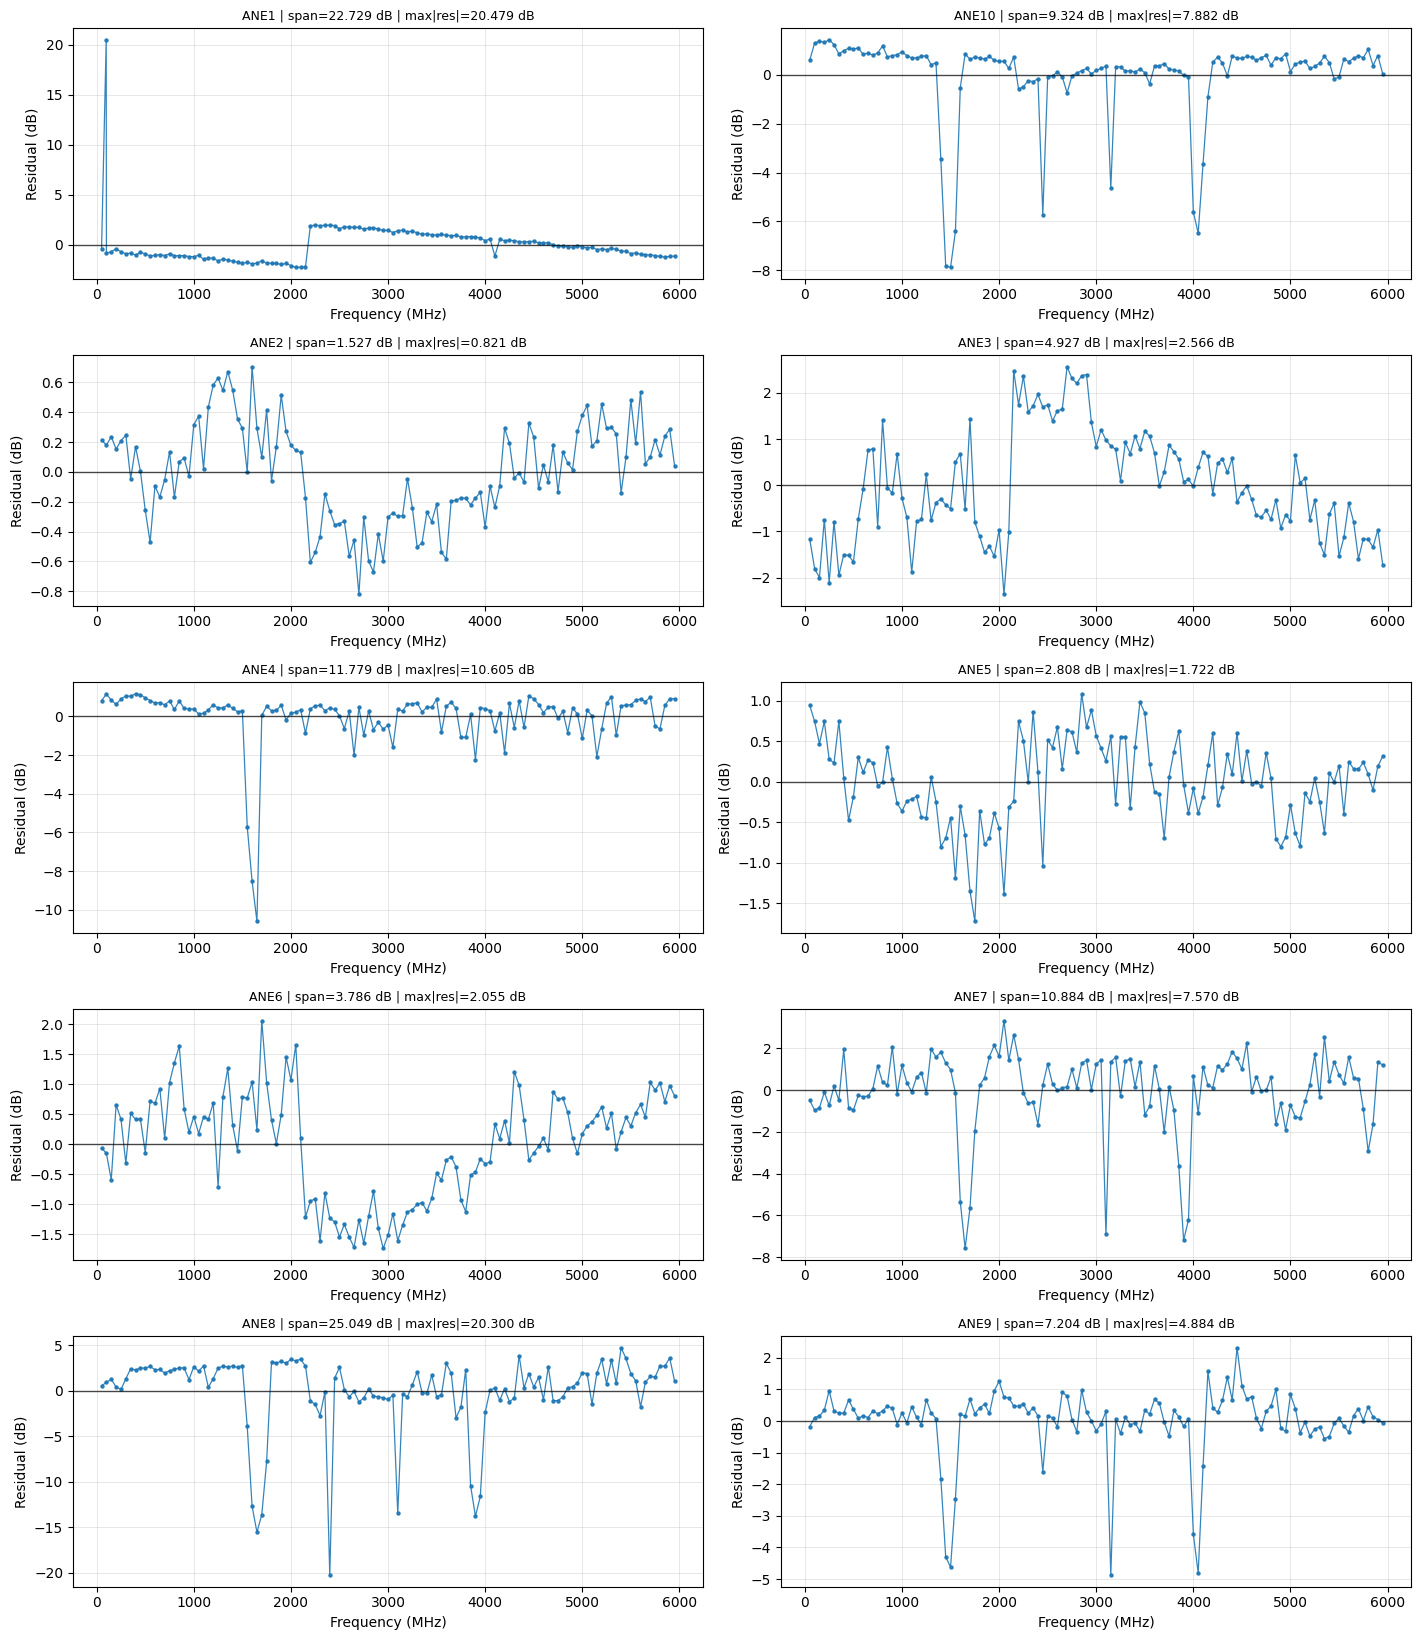

In [23]:
res_fig, res_axes, linearity_residual_plot_path = plot_linearity_residual_by_sensor(
    linearity_summary_df=linearity_summary_df,
    fit_payload_by_sensor=linearity_fit_payload_by_sensor,
    output_dir=OUTPUT_DIR,
    output_filename=LINEARITY_RESIDUAL_PLOT_FILENAME,
    ncols=LINEARITY_PLOT_NCOLS,
)
print(f"Saved linearity residual plot to: {linearity_residual_plot_path}")
plt.show()


In [24]:
# Optional exports for downstream reporting.
sensor_summary_csv_path = Path("data/danl_sensor_summary.csv")
linearity_summary_csv_path = Path("data/danl_linearity_summary.csv")

sensor_summary_csv_path.parent.mkdir(parents=True, exist_ok=True)
sensor_summary_df.to_csv(sensor_summary_csv_path, index=False)
linearity_summary_df.to_csv(linearity_summary_csv_path, index=False)

print(f"Saved DANL summary table to: {sensor_summary_csv_path}")
print(f"Saved linearity summary table to: {linearity_summary_csv_path}")


Saved DANL summary table to: data/danl_sensor_summary.csv
Saved linearity summary table to: data/danl_linearity_summary.csv
